# Install & Import Libraries

In [ ]:
# install lib
!pip install -q openpyxl scikit-learn

In [ ]:
# import some librariies
import os
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# set reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed = 42
set_seed(seed)

In [ ]:
# config
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15
LR = 1e-4

# path dataset
DATASET_DIR = Path('/content/drive/MyDrive/LeFood-Set')
EXCEL_PATH = DATASET_DIR / 'data_original.xlsx'

BEFORE_ROOT = DATASET_DIR / 'leftover dataset' / 'data_before'
AFTER_ROOT  = DATASET_DIR / 'leftover dataset' / 'data_after'

# print path
print('Dataset Path:', DATASET_DIR)
print('Excel Path:', EXCEL_PATH)

Dataset Path: /content/drive/MyDrive/LeFood-Set
Excel Path: /content/drive/MyDrive/LeFood-Set/data_original.xlsx


In [ ]:
# read file excel
df = pd.read_excel(EXCEL_PATH)

# load metadata
def build_file_index(root: Path):
    index = {}
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
            index[p.name] = str(p)
    return index

before_index = build_file_index(BEFORE_ROOT)
after_index = build_file_index(AFTER_ROOT)

df['before_path'] = df['Image Before Eaten'].astype(str).str.strip().map(before_index)
df['after_path'] = df['Image After Eaten'].astype(str).str.strip().map(after_index)

df['weight_before'] = pd.to_numeric(df['Weight Before Eaten (g)'], errors='coerce')
df['weight_after'] = pd.to_numeric(df['Weight After Eaten (g)'], errors='coerce')

# result valid data
df = df.dropna(subset=['before_path', 'after_path', 'weight_before', 'weight_after']).reset_index(drop=True)
df.head()

,ID,Name of the food,Image Before Eaten,Weight Before Eaten (g),Image After Eaten,Weight After Eaten (g),Visual Estimation by Observer (1-7),before_path,after_path,weight_before,weight_after
0,1,Bubur,000_000_DSC_0016_bef.JPG,343,000_000_DSC_0032_aft.JPG,330,1,/content/drive/MyDrive/LeFood-Set/leftover dat...,/content/drive/MyDrive/LeFood-Set/leftover dat...,343,330
1,2,Nasi,001_001_DSC_0059_bef.JPG,130,001_001_DSC_0108_aft.JPG,122,3,/content/drive/MyDrive/LeFood-Set/leftover dat...,/content/drive/MyDrive/LeFood-Set/leftover dat...,130,122
2,3,Nasi,001_002_DSC_0066_bef.JPG,135,001_002_DSC_0095_aft.JPG,127,1,/content/drive/MyDrive/LeFood-Set/leftover dat...,/content/drive/MyDrive/LeFood-Set/leftover dat...,135,127
3,4,Nasi,001_003_DSC_0067_bef.JPG,146,001_003_DSC_0097_aft.JPG,1,7,/content/drive/MyDrive/LeFood-Set/leftover dat...,/content/drive/MyDrive/LeFood-Set/leftover dat...,146,1
4,5,Nasi,001_008_DSC_0055_bef.JPG,139,001_008_DSC_0101_aft.JPG,25,6,/content/drive/MyDrive/LeFood-Set/leftover dat...,/content/drive/MyDrive/LeFood-Set/leftover dat...,139,25


# Data Understanding

In [ ]:
# cek shape data
print('Jumlah data valid:', df.shape)

Jumlah data valid: (524, 11)


In [ ]:
# cek info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   ID                                   524 non-null    int64 
 1   Name of the food                     524 non-null    object
 2   Image Before Eaten                   524 non-null    object
 3   Weight Before Eaten (g)              524 non-null    int64 
 4   Image After Eaten                    524 non-null    object
 5   Weight After Eaten (g)               524 non-null    int64 
 6   Visual Estimation by Observer (1-7)  524 non-null    int64 
 7   before_path                          524 non-null    object
 8   after_path                           524 non-null    object
 9   weight_before                        524 non-null    int64 
 10  weight_after                         524 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 45.2+ KB

# Feature Engineerinng

In [ ]:
# filter data lebih dari 0
df = df[df['weight_before'] > 0].copy().reset_index(drop=True)

df['after_ratio'] = df['weight_after'] / df['weight_before']
df['after_ratio'] = df['after_ratio'].clip(0.0, 1.0)

print(df[['weight_before', 'weight_after', 'after_ratio']].head())

   weight_before  weight_after  after_ratio
0            343           330     0.962099
1            130           122     0.938462
2            135           127     0.940741
3            146             1     0.006849
4            139            25     0.179856


# Eksploratory Data Analysis (EDA)

In [ ]:
# cek desct stats
print(df[['weight_before', 'weight_after', 'after_ratio']].describe().round(4))

       weight_before  weight_after  after_ratio
count       524.0000      524.0000     524.0000
mean         73.2309       28.6489       0.3786
std          57.4086       43.6170       0.4040
min           4.0000        0.0000       0.0000
25%          32.0000        0.0000       0.0000
50%          46.0000       11.5000       0.2115
75%         129.0000       37.2500       0.8066
max         343.0000      330.0000       1.0000


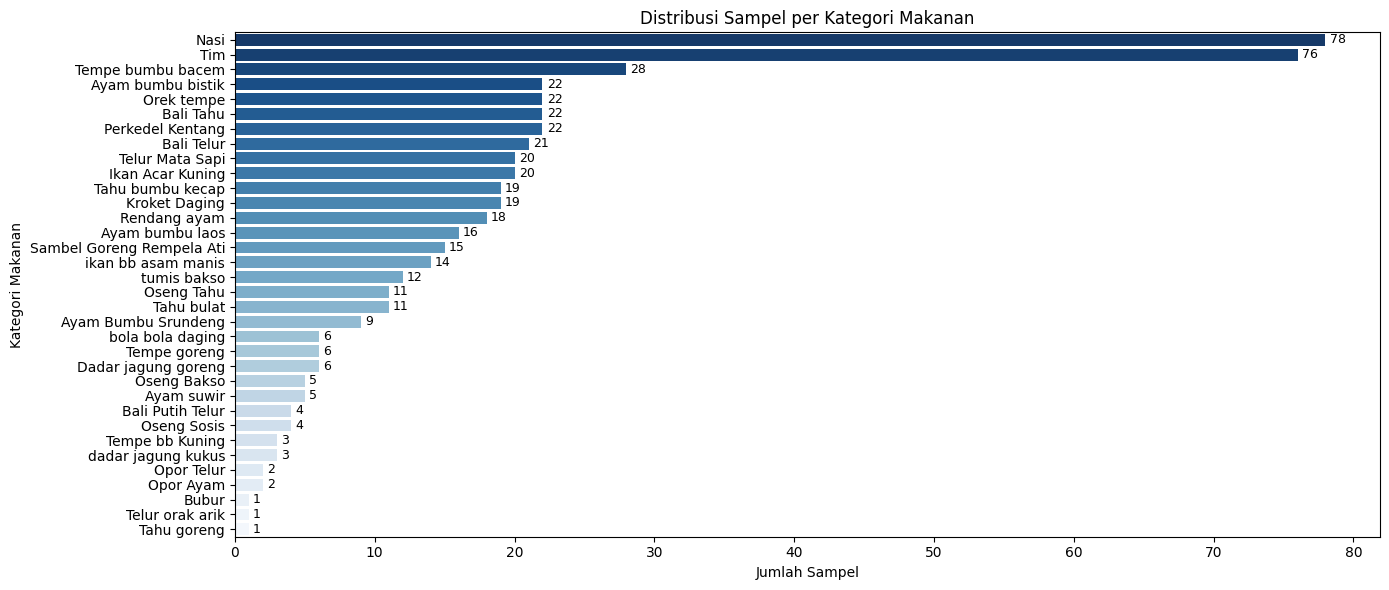

Terbanyak : Nasi (78 sampel)
Tersedikit: Tahu goreng (1 sampel)


In [ ]:
# visualisasi distribusi sampel per kategori
class_counts = df.groupby('Name of the food').size().reset_index(name='total')
class_counts = class_counts.sort_values('total', ascending=False).reset_index(drop=True)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=class_counts, y='Name of the food', x='total', palette='Blues_r')

for bar, val in zip(ax.patches, class_counts['total']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Jumlah Sampel')
ax.set_ylabel('Kategori Makanan')
ax.set_title('Distribusi Sampel per Kategori Makanan')
plt.tight_layout()
plt.show()

print(f'Terbanyak : {class_counts.iloc[0]['Name of the food']} ({class_counts.iloc[0]['total']} sampel)')
print(f'Tersedikit: {class_counts.iloc[-1]['Name of the food']} ({class_counts.iloc[-1]['total']} sampel)')

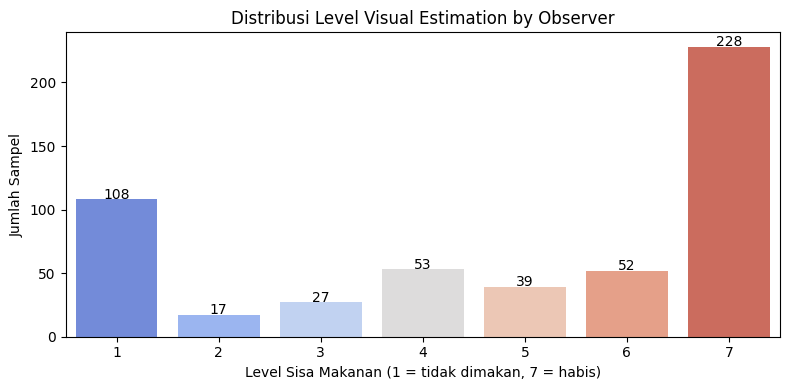

In [ ]:
# visualisasi distrbiusi visual estimation level
visual_counts = df['Visual Estimation by Observer (1-7)'].value_counts().sort_index().reset_index()
visual_counts.columns = ['level', 'count']

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=visual_counts, x='level', y='count', palette='coolwarm')

for bar, val in zip(ax.patches, visual_counts['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=10)

ax.set_xlabel('Level Sisa Makanan (1 = tidak dimakan, 7 = habis)')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Level Visual Estimation by Observer')
plt.tight_layout()
plt.show()

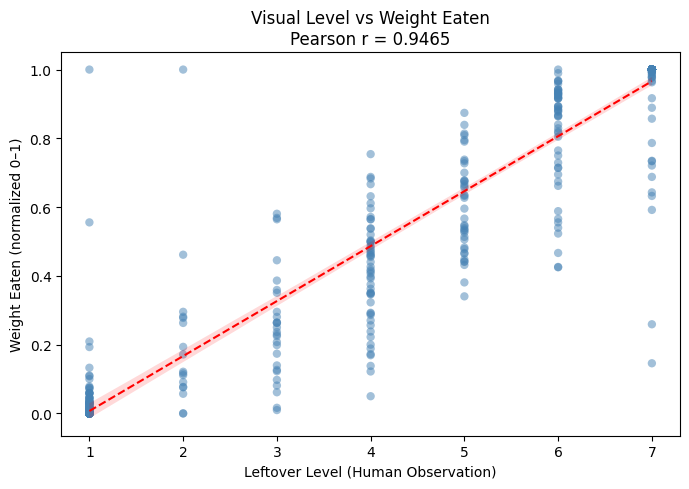

Pearson r = 0.9465


In [ ]:
# visualisasi korelasi visual lvl vs weight eaten
df['weight_eaten_norm'] = 1 - df['after_ratio']
pearson_r, _ = pearsonr(df['Visual Estimation by Observer (1-7)'], df['weight_eaten_norm'])

plt.figure(figsize=(7, 5))
ax = sns.scatterplot(data=df, x='Visual Estimation by Observer (1-7)', y='weight_eaten_norm',
                     alpha=0.5, color='steelblue', edgecolor='none')
sns.regplot(data=df, x='Visual Estimation by Observer (1-7)', y='weight_eaten_norm',
            scatter=False, color='red', line_kws={'linestyle': '--', 'linewidth': 1.5})

ax.set_xticks([1,2,3,4,5,6,7])
ax.set_xlabel('Leftover Level (Human Observation)')
ax.set_ylabel('Weight Eaten (normalized 0–1)')
ax.set_title(f'Visual Level vs Weight Eaten\nPearson r = {pearson_r:.4f}')
plt.tight_layout()
plt.show()

print(f'Pearson r = {pearson_r:.4f}')

In [ ]:
# visualisasi stats weight per visual lvl
stats = df.groupby('Visual Estimation by Observer (1-7)')['weight_eaten_norm'].agg(
    mean_weight=lambda x: round(x.mean(), 3),
    std_weight=lambda x: round(x.std(), 3),
    count='count'
).reset_index()
stats.columns = ['Leftover Level', 'Mean Weight Eaten', 'Std', 'Count']
print(stats.to_string(index=False))

 Leftover Level  Mean Weight Eaten   Std  Count
              1              0.036 0.113    108
              2              0.211 0.237     17
              3              0.252 0.158     27
              4              0.414 0.159     53
              5              0.603 0.137     39
              6              0.817 0.157     52
              7              0.980 0.094    228


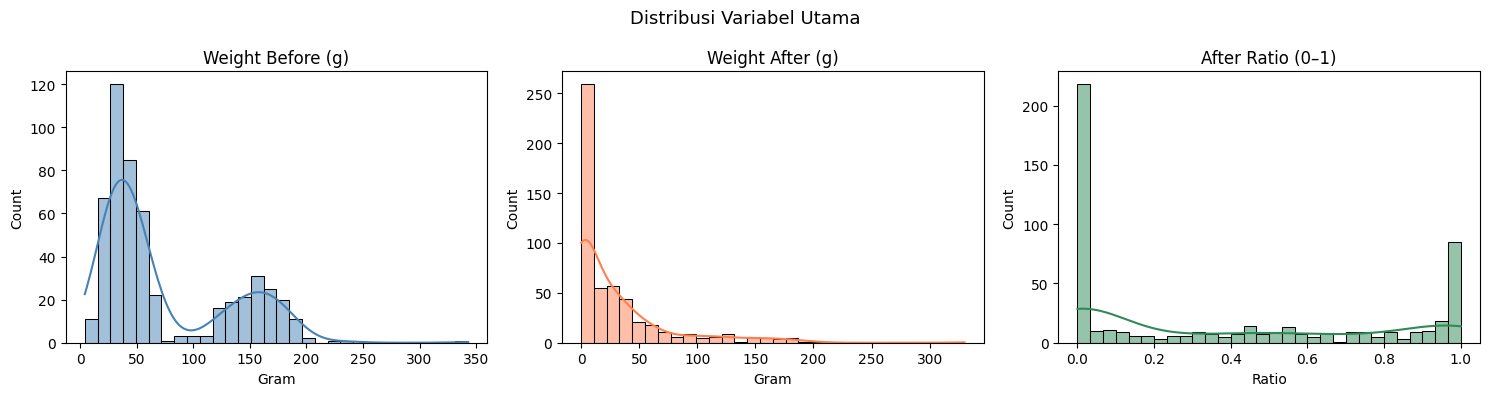

In [ ]:
# visualisasi distribus weight before, after dn ratio
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['weight_before'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Weight Before (g)')
axes[0].set_xlabel('Gram')

sns.histplot(df['weight_after'], bins=30, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Weight After (g)')
axes[1].set_xlabel('Gram')

sns.histplot(df['after_ratio'], bins=30, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('After Ratio (0–1)')
axes[2].set_xlabel('Ratio')

plt.suptitle('Distribusi Variabel Utama', fontsize=13)
plt.tight_layout()
plt.show()

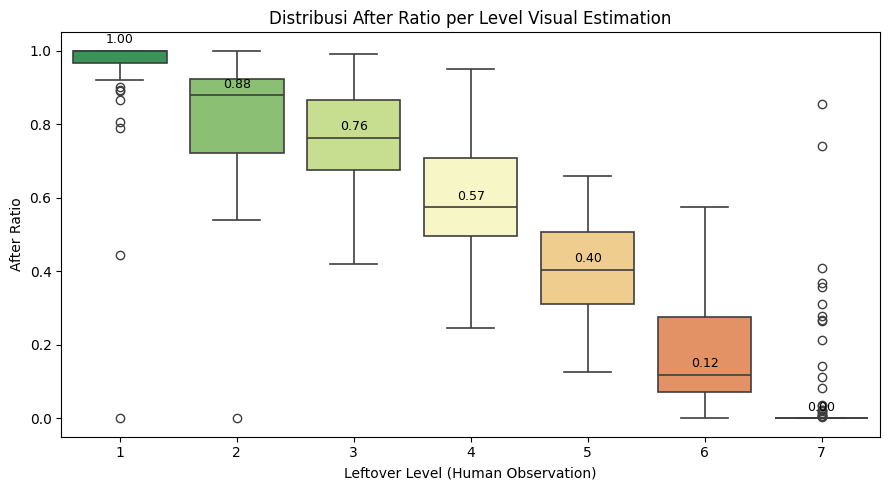

In [ ]:
# visualisasi boxplot after ration per visual lvl
plt.figure(figsize=(9, 5))
ax = sns.boxplot(data=df, x='Visual Estimation by Observer (1-7)', y='after_ratio',
                 palette='RdYlGn_r', linewidth=1.2)

medians = df.groupby('Visual Estimation by Observer (1-7)')['after_ratio'].median()
for i, (lvl, med) in enumerate(medians.items()):
    ax.text(i, med + 0.02, f'{med:.2f}', ha='center', fontsize=9,
            color='black')

ax.set_xlabel('Leftover Level (Human Observation)')
ax.set_ylabel('After Ratio')
ax.set_title('Distribusi After Ratio per Level Visual Estimation')
plt.tight_layout()
plt.show()

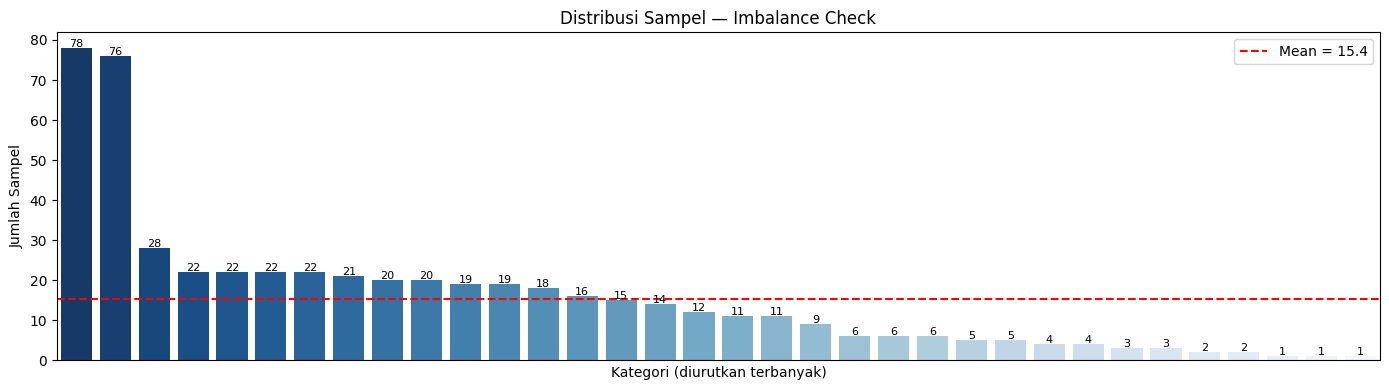

Imbalance ratio (max/min): 78.0x
Kategori dengan < 5 sampel: 9 kategori


In [ ]:
# imbalanced check
plt.figure(figsize=(14, 4))
ax = sns.barplot(data=class_counts, x=class_counts.index, y='total',
                 palette='Blues_r')

ax.axhline(class_counts['total'].mean(), color='red', linestyle='--',
           label=f'Mean = {class_counts['total'].mean():.1f}')

for bar, val in zip(ax.patches, class_counts['total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontsize=8)

ax.set_xlabel('Kategori (diurutkan terbanyak)')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Sampel — Imbalance Check')
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.show()

print(f'Imbalance ratio (max/min): {class_counts['total'].max() / class_counts['total'].min():.1f}x')
print(f'Kategori dengan < 5 sampel: {(class_counts['total'] < 5).sum()} kategori')

# Splitting Data

In [ ]:
# train test split (train/val/test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=seed
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=1/3,
    random_state=seed
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('Train:', len(train_df))
print('Val:', len(val_df))
print('Test :', len(test_df))

Train: 366
Val: 105
Test : 53


**Rasio Split:**

Train = 70% / Val = 20% / Test = 10%

In [ ]:
# data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name='data_augmentation')

# function load img
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img

In [ ]:
# function build dataset (dual input pipeline)
def make_dataset(dataframe, training=False):
    before_paths = dataframe['before_path'].values
    after_paths = dataframe['after_path'].values
    ratios = dataframe['after_ratio'].values.astype('float32')
    wb = dataframe['weight_before'].values.astype('float32')
    wa = dataframe['weight_after'].values.astype('float32')

    ds = tf.data.Dataset.from_tensor_slices((before_paths, after_paths, ratios, wb, wa))

    if training:
        ds = ds.shuffle(len(dataframe), seed=42)

    def map(before_path, after_path, ratio, weight_before, weight_after):
        before_img = load_image(before_path)
        after_img = load_image(after_path)

        before_img = tf.keras.applications.efficientnet.preprocess_input(before_img)
        after_img = tf.keras.applications.efficientnet.preprocess_input(after_img)

        features = {
            'before_image' : before_img,
            'after_image' : after_img,
            'weight_before': weight_before,
            'weight_after' : weight_after
        }
        return features, ratio

    ds = ds.map(map, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        def augment(features, target):
            features['before_image'] = data_augmentation(features['before_image'], training=True)
            features['after_image'] = data_augmentation(features['after_image'],  training=True)
            return features, target
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# apply ke train/test/val
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# Build Model

In [ ]:
# function dual input model
def build_dual_input_model():
    before_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='before_image') # img before
    after_input  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='after_image') # img after

    # pake efficient net B0
    backbone = tf.keras.applications.EfficientNetB0(
        include_top = False,
        weights = 'imagenet',
        pooling = 'avg'
    )
    backbone.trainable = False

    feat_before = backbone(before_input) # backbone before
    feat_after = backbone(after_input) # backbone after

    x   = layers.Concatenate(name='fusion_concat')([feat_before, feat_after])
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid', name='after_ratio')(x) # regression

    model = keras.Model(
        inputs=[before_input, after_input],
        outputs=out,
        name='dual_input_efficientnet_regressor'
    )
    return model

# summary model
model = build_dual_input_model()
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "dual_input_efficientnet_regressor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ before_image        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ after_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 1280)      │  4,049,571 │ before_image[0][… │
│ (Functional)        │                   │            │ after_image[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 2560)      │          0 │ efficientnetb0[0… │
│ (Concatenate)       │                   │            │ efficientnetb0[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2560)      │          0 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    655,616 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ after_ratio (Dense) │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,705,444 (17.95 MB)

 Trainable params: 655,873 (2.50 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

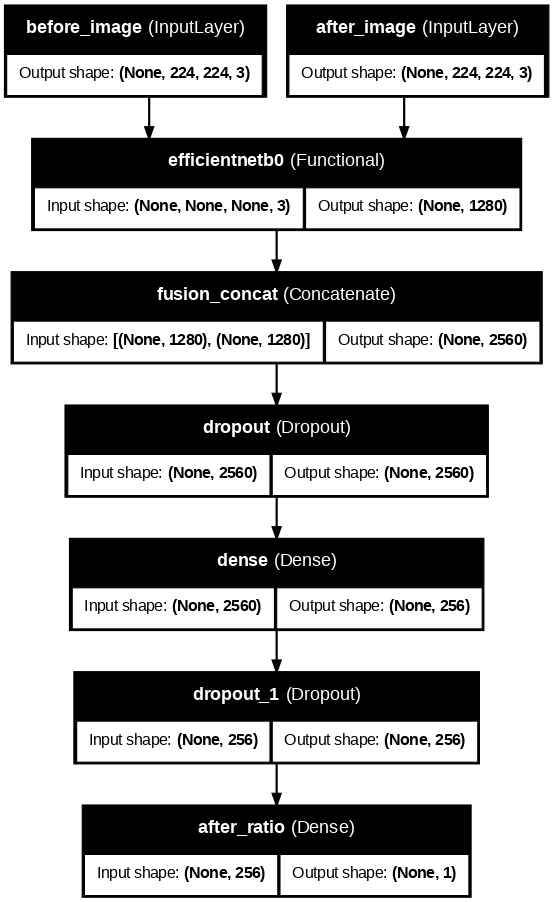

In [ ]:
# visualisasi model
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, dpi=80)

## Arsitektur Model: Dual-Input EfficientNetB0 Regressor

Model ini dirancang untuk menerima **dua gambar sekaligus** (before & after) dan memprediksi rasio sisa makanan dalam satu nilai kontinu (0–1).

---

### Alur Arsitektur
```
before_image (224×224×3) ──┐
                            ├──→ EfficientNetB0 ──→ fusion_concat ──→ Dropout ──→ Dense(256) ──→ Dropout ──→ after_ratio
after_image  (224×224×3) ──┘
```

---

### Detail Tiap Layer

| Layer | Tipe | Input Shape | Output Shape | Keterangan |
|---|---|---|---|---|
| `before_image` | InputLayer | — | (None, 224, 224, 3) | Gambar sebelum makan |
| `after_image` | InputLayer | — | (None, 224, 224, 3) | Gambar sesudah makan |
| `efficientnetb0` | Functional | (None, None, None, 3) | (None, 1280) | Backbone pretrained ImageNet, **frozen** (shared untuk kedua input) |
| `fusion_concat` | Concatenate | [(None, 1280), (None, 1280)] | (None, 2560) | Gabungan fitur before & after |
| `dropout` | Dropout(0.2) | (None, 2560) | (None, 2560) | Regularisasi |
| `dense` | Dense(256, ReLU) | (None, 2560) | (None, 256) | Pembelajaran pola fusion |
| `dropout_1` | Dropout(0.2) | (None, 256) | (None, 256) | Regularisasi |
| `after_ratio` | Dense(1, Sigmoid) | (None, 256) | (None, 1) | Output: rasio sisa (0–1) |

---

### Poin Penting

- **Shared backbone**: EfficientNetB0 yang sama digunakan untuk mengekstrak fitur dari kedua gambar, sehingga representasi fiturnya sebanding
- **Full freeze**: Seluruh bobot EfficientNetB0 tidak diupdate saat training — hanya layer Dense yang belajar
- **Fusion via Concatenate**: Vektor fitur 1280 dari before dan after digabung menjadi 2560, memungkinkan model membandingkan perubahan visual secara implisit
- **Output Sigmoid**: Memastikan prediksi selalu berada di rentang [0, 1], sesuai dengan definisi `after_ratio = weight_after / weight_before`
- **Konversi ke gram**: `pred_after_g = pred_ratio × weight_before`

In [ ]:
# compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='mae', # loss pake mae (karena lebih robust dari outlier)
    metrics=[
        keras.metrics.MeanAbsoluteError(name='mae'),
        keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

# set callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

## Training

In [ ]:
# training loop
history = model.fit(
    train_ds.map(lambda x, y: ((x['before_image'], x['after_image']), y)),
    validation_data=val_ds.map(lambda x, y: ((x['before_image'], x['after_image']), y)),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 239s 9s/step - loss: 0.3341 - mae: 0.3341 - rmse: 0.4077 - val_loss: 0.2842 - val_mae: 0.2842 - val_rmse: 0.3602 - learning_rate: 1.0000e-04
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - loss: 0.2417 - mae: 0.2417 - rmse: 0.3069 - val_loss: 0.1934 - val_mae: 0.1934 - val_rmse: 0.2448 - learning_rate: 1.0000e-04
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - loss: 0.1906 - mae: 0.1906 - rmse: 0.2576 - val_loss: 0.1597 - val_mae: 0.1597 - val_rmse: 0.2228 - learning_rate: 1.0000e-04
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - loss: 0.1676 - mae: 0.1676 - rmse: 0.2388 - val_loss: 0.1412 - val_mae: 0.1412 - val_rmse: 0.1896 - learning_rate: 1.0000e-04
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - loss: 0.1388 - mae: 0.1388 - rmse: 0.2072 - val_loss: 0.1264 - val_mae: 0.1264 - val_rmse: 0.1821 - learning_rate: 1.0000e-04
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - loss: 0.1279 - mae: 0.1279 - rmse: 0.2010 - val_loss: 0.1

# Evaluasi Model

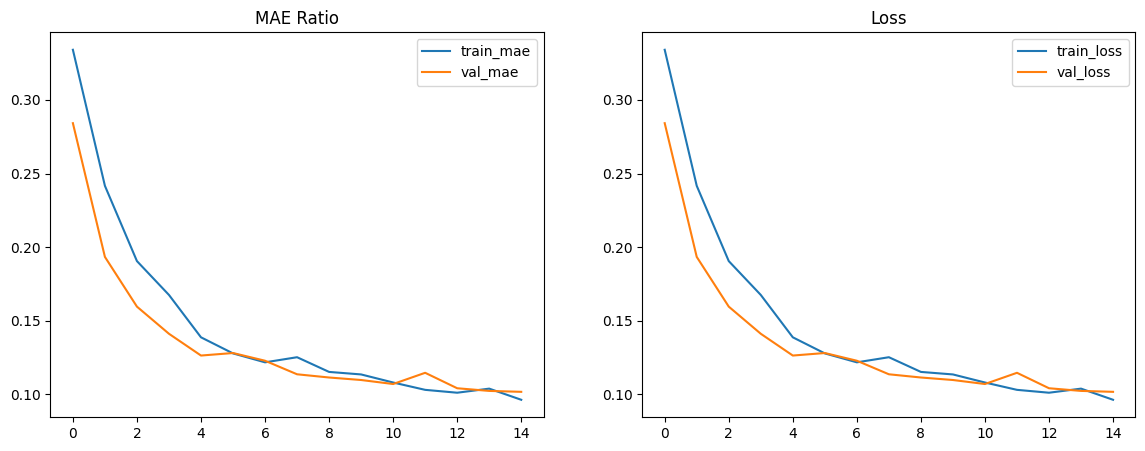

In [ ]:
# plot training history
hist = pd.DataFrame(history.history)

plt.figure(figsize=(14, 5))

plt.subplot(1,2,1)
plt.plot(hist['mae'], label='train_mae')
plt.plot(hist['val_mae'], label='val_mae')
plt.title('MAE Ratio')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.show()

dari kurva training diatas menunjukkan model belajar dengan baik dan stabil. nilai MAE maupun loss keduanya turun konsisten dari epoch 0 hingga sekitar epoch 8–9, lalu mulai mendatar yg artinya model sudah konvergen.

Tidak ada tanda-tanda overfitting yang signifikan karena val_mae dan train_mae bergerak berdekatan sepanjang training. Nilai akhir MAE ratio di sekitar 0.10–0.11 pada kedua set menunjukkan performa yang konsisten antara training dan validasi.

In [ ]:
# function evaluate model
def evaluate_model_dual(model, dataframe):
    before_images, after_images = [], []

    for bp, ap in zip(dataframe['before_path'].values, dataframe['after_path'].values):
        b = load_image(bp)
        a = load_image(ap)
        b = tf.keras.applications.efficientnet.preprocess_input(b)
        a = tf.keras.applications.efficientnet.preprocess_input(a)
        before_images.append(b.numpy())
        after_images.append(a.numpy())

    before_images = np.stack(before_images, axis=0)
    after_images = np.stack(after_images,  axis=0)

    pred_ratio = model.predict([before_images, after_images], batch_size=BATCH_SIZE).reshape(-1)
    pred_ratio = np.clip(pred_ratio, 0.0, 1.0)

    y_true_ratio = dataframe['after_ratio'].values.astype('float32')
    weight_before = dataframe['weight_before'].values.astype('float32')
    y_true_g = dataframe['weight_after'].values.astype('float32')
    pred_after_g = np.clip(pred_ratio * weight_before, 0.0, None)

    mae_ratio = mean_absolute_error(y_true_ratio, pred_ratio)
    rmse_ratio = math.sqrt(mean_squared_error(y_true_ratio, pred_ratio))
    r2_ratio = r2_score(y_true_ratio, pred_ratio)

    mae_g = mean_absolute_error(y_true_g, pred_after_g)
    rmse_g = math.sqrt(mean_squared_error(y_true_g, pred_after_g))
    r2_g = r2_score(y_true_g, pred_after_g)

    print('test metrics (gram)')
    print(f'MAE : {mae_g:.4f} g')
    print(f'RMSE : {rmse_g:.4f} g')
    print(f'R2 : {r2_g:.4f}')
    print()
    print('test metrics (ratio)')
    print(f'MAE : {mae_ratio:.4f}')
    print(f'RMSE : {rmse_ratio:.4f}')
    print(f'R2 : {r2_ratio:.4f}')

    return {
        'y_true_ratio': y_true_ratio, 'y_pred_ratio': pred_ratio,
        'y_true_g' : y_true_g, 'y_pred_g' : pred_after_g,
        'weight_before': weight_before,
        'mae_g': mae_g, 'rmse_g': rmse_g, 'r2_g': r2_g
    }

# apply function evaluate
results = evaluate_model_dual(model, test_df)

4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step
test metrics (gram)
MAE : 6.3659 g
RMSE : 12.2988 g
R2 : 0.9430

test metrics (ratio)
MAE : 0.0665
RMSE : 0.1084
R2 : 0.9315


Model mencapai R² sebesar 0.94 dengan MAE 6.46 gram pada test set, menunjukkan prediksi yang cukup akurat. RMSE yang lebih tinggi (12.78 gram) mengindikasikan adanya beberapa outlier error, kemungkinan pada kategori makanan dengan tampilan ambigu. Menariknya, MAE ratio sebesar 0.0707 berhasil melampaui human observation (0.0926) dari jurnal acuan, meskipun model ini hanya menggunakan pendekatan single-task tanpa klasifikasi makanan.

## Naive Baseline

In [ ]:
# naive baseline
mean_weight_after_train = train_df['weight_after'].mean() # prediksi semua sampel = rata-rata weight_after dari data train

naive_pred = np.full(shape=len(test_df), fill_value=mean_weight_after_train)
y_true_g   = test_df['weight_after'].values.astype('float32')

naive_mae  = mean_absolute_error(y_true_g, naive_pred)
naive_rmse = math.sqrt(mean_squared_error(y_true_g, naive_pred))
naive_r2   = r2_score(y_true_g, naive_pred)

print('naive baseline (mean weight_after train)')
print(f'MAE  : {naive_mae:.4f} g')
print(f'RMSE : {naive_rmse:.4f} g')
print(f'R2   : {naive_r2:.4f}')

naive baseline (mean weight_after train)
MAE  : 29.9367 g
RMSE : 51.5203 g
R2   : -0.0010


In [ ]:
# baseline (mirip di jurnal)
# konversi visual level 1-7 ke rasio (sama seperti jurnal)
df['visual_pred_ratio'] = 1 - (df['Visual Estimation by Observer (1-7)'] / 7)

human_mae  = mean_absolute_error(df.loc[test_df.index, 'after_ratio'],
                                  df.loc[test_df.index, 'visual_pred_ratio'])
print(f'Human Observation MAE: {human_mae:.4f}')

Human Observation MAE: 0.1182


Model jauh mengungguli kedua baseline. Dibanding naive baseline yang hanya menebak rata-rata (MAE 29.94 gram, R² ≈ 0), model berhasil menekan error hingga 4.6× lebih kecil (MAE 6.46 gram).

Dibanding human observation, MAE ratio model (0.0707) juga lebih baik dari estimasi visual manusia (0.1182), membuktikan pendekatan deep learning ini layak menggantikan observasi manual di setting rumah sakit.

fungsi naive baseline:
1. Buat pembanding (model beneran belajar atau cuma 'asal tebak')
2. Validasi kualitas model (model = baseline berarti model jelek, model jauh lebih baik dari baseline = model bagus)
3. Sebagai bukti ilmiah

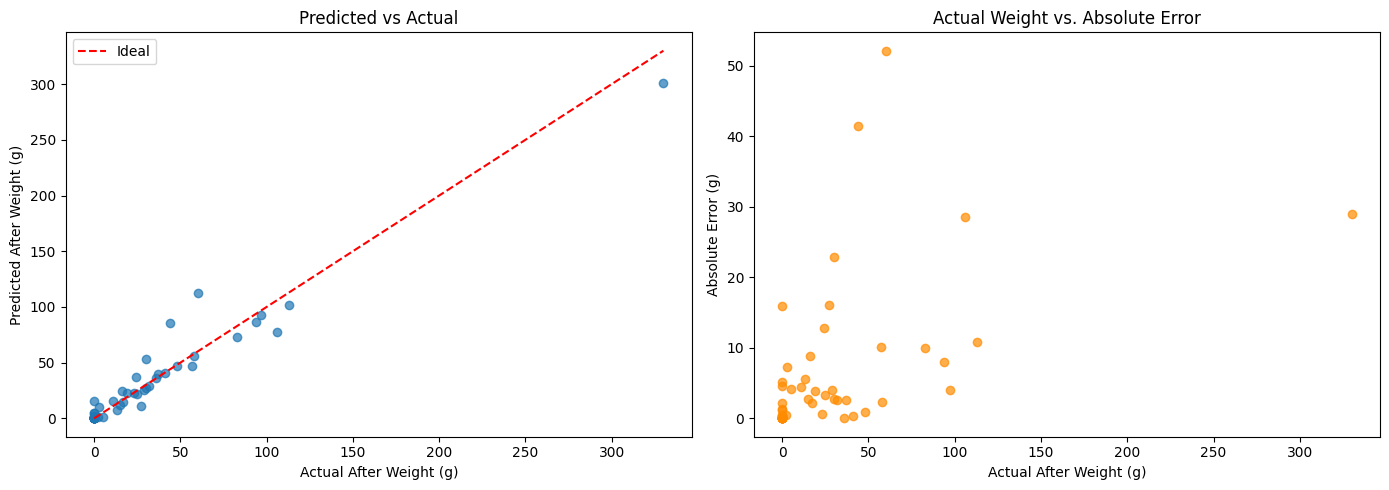

In [ ]:
# scatter plot untuk evaluate model
y_true = results['y_true_g']
y_pred = results['y_pred_g']

plt.figure(figsize=(14 ,5))

# plot actual vs predicted
plt.subplot(1,2,1)
plt.scatter(y_true, y_pred, alpha=0.7)
mx = max(y_true.max(), y_pred.max())
plt.plot([0, mx], [0, mx], 'r--', label='Ideal')
plt.xlabel('Actual After Weight (g)')
plt.ylabel('Predicted After Weight (g)')
plt.title('Predicted vs Actual')
plt.legend()

# plot residual
plt.subplot(1,2,2)
abs_err = np.abs(y_true - y_pred)
plt.scatter(y_true, abs_err, alpha=0.7, color='darkorange')
plt.xlabel('Actual After Weight (g)')
plt.ylabel('Absolute Error (g)')
plt.title('Actual Weight vs. Absolute Error')

plt.tight_layout()
plt.show()

Sebagian besar prediksi mengikuti garis ideal dengan baik, terutama pada rentang berat rendah (0–80 gram) yang memang mendominasi dataset. Terlihat beberapa outlier di rentang menengah (50–100 gram) dengan error hingga 40–50 gram, yang kemungkinan berasal dari kategori makanan dengan tampilan ambigu

Pola error di grafik kanan tidak menunjukkan tren sistematis, artinya error tidak bias ke berat tertentu.

In [ ]:
# contoh sample prediction
show_df = test_df.copy().reset_index(drop=True)
show_df['pred_ratio'] = results['y_pred_ratio']
show_df['pred_after_g'] = results['y_pred_g']
show_df['abs_error_g'] = np.abs(show_df['weight_after'] - show_df['pred_after_g'])

show_df[['Name of the food', 'weight_before', 'weight_after', 'after_ratio',
         'pred_ratio', 'pred_after_g', 'abs_error_g']].head(10)

,Name of the food,weight_before,weight_after,after_ratio,pred_ratio,pred_after_g,abs_error_g
0,Tempe bumbu bacem,41,41,1.00000,0.991812,40.664272,0.335728
1,Ayam suwir,32,11,0.34375,0.483249,15.463963,4.463963
2,Dadar jagung goreng,29,29,1.00000,0.863506,25.041674,3.958326
3,Ayam bumbu laos,58,58,1.00000,0.960981,55.736900,2.263100
4,Tempe bumbu bacem,36,0,0.00000,0.009379,0.337654,0.337654
5,Orek tempe,41,0,0.00000,0.031042,1.272738,1.272738
6,Bali Telur,51,0,0.00000,0.002032,0.103655,0.103655
7,Tahu bumbu kecap,40,37,0.92500,0.992018,39.680740,2.680740
8,Kroket Daging,21,0,0.00000,0.002911,0.061136,0.061136
9,Nasi,114,0,0.00000,0.019673,2.242773,2.242773


# Cross Validation (Test Robustness)

Dijalankan sebagai **validasi tambahan** setelah training utama selesai.
Tujuannya untuk mengukur stabilitas dan generalisasi model secara lebih robust.

In [ ]:
# cross val
N_FOLDS = 5 # pake 5 kfold
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

# gabung train+val untuk CV (test_df tidak disentuh)
df_cv = pd.concat([train_df, val_df]).reset_index(drop=True)

fold_results = []

cv_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=0
    )
]

# training cross val loop
for fold, (train_idx, val_idx) in enumerate(kf.split(df_cv)):
    print(f'FOLD {fold+1} / {N_FOLDS}')

    fold_train = df_cv.iloc[train_idx].reset_index(drop=True)
    fold_val = df_cv.iloc[val_idx].reset_index(drop=True)
    print(f'Train: {len(fold_train)} | Val: {len(fold_val)}')

    fold_train_ds = make_dataset(fold_train, training=True)
    fold_val_ds = make_dataset(fold_val,   training=False)

    # build & compile ulang tiap fold agar bobot tidak terbawa
    fold_model = build_dual_input_model()
    fold_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='mae',
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
    )

    # fit tiap fold
    fold_model.fit(
        fold_train_ds.map(lambda x, y: ((x['before_image'], x['after_image']), y)),
        validation_data=fold_val_ds.map(lambda x, y: ((x['before_image'], x['after_image']), y)),
        epochs=EPOCHS,
        callbacks=cv_callbacks,
        verbose=1
    )

    # evaluate tiap fold
    res = evaluate_model_dual(fold_model, fold_val)
    fold_results.append(res)
    print(f'Fold {fold+1} MAE: {res['mae_g']:.4f} g | RMSE: {res['rmse_g']:.4f} g | R2: {res['r2_g']:.4f}')

# summary
mae_list = [r['mae_g'] for r in fold_results]
rmse_list = [r['rmse_g'] for r in fold_results]
r2_list = [r['r2_g'] for r in fold_results]

FOLD 1 / 5
Train: 376 | Val: 95
Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 120s 4s/step - loss: 0.3186 - mae: 0.3186 - val_loss: 0.2311 - val_mae: 0.2311 - learning_rate: 1.0000e-04
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - loss: 0.2131 - mae: 0.2131 - val_loss: 0.1589 - val_mae: 0.1589 - learning_rate: 1.0000e-04
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - loss: 0.1714 - mae: 0.1714 - val_loss: 0.1437 - val_mae: 0.1437 - learning_rate: 1.0000e-04
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - loss: 0.1629 - mae: 0.1629 - val_loss: 0.1286 - val_mae: 0.1286 - learning_rate: 1.0000e-04
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - loss: 0.1403 - mae: 0.1403 - val_loss: 0.1047 - val_mae: 0.1047 - learning_rate: 1.0000e-04
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - loss: 0.1365 - mae: 0.1365 - val_loss: 0.1029 - val_mae: 0.1029 - learning_rate: 1.0000e-04
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - loss: 0.1206 - mae: 0.1206 - val_loss: 0.0953 - val

6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step
test metrics (gram)
MAE : 20.1372 g
RMSE : 33.3181 g
R2 : 0.5118

test metrics (ratio)
MAE : 0.2388
RMSE : 0.2948
R2 : 0.4519
Fold 2 MAE: 20.1372 g | RMSE: 33.3181 g | R2: 0.5118
FOLD 3 / 5
Train: 377 | Val: 94
Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 119s 4s/step - loss: 0.3212 - mae: 0.3212 - val_loss: 0.2415 - val_mae: 0.2415 - learning_rate: 1.0000e-04
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - loss: 0.2129 - mae: 0.2129 - val_loss: 0.2081 - val_mae: 0.2081 - learning_rate: 1.0000e-04
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - loss: 0.1720 - mae: 0.1720 - val_loss: 0.1872 - val_mae: 0.1872 - learning_rate: 5.0000e-05
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - loss: 0.1598 - mae: 0.1598 - val_loss: 0.1957 - val_mae: 0.1957 - learning_rate: 5.0000e-05
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - loss: 0.1583 - mae: 0.1583 - val_loss: 0.1787 - val_mae: 0.1787 - learning_rate: 2.5000e-05


6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step
test metrics (gram)
MAE : 17.4078 g
RMSE : 26.1131 g
R2 : 0.5485

test metrics (ratio)
MAE : 0.2415
RMSE : 0.2991
R2 : 0.3991
Fold 3 MAE: 17.4078 g | RMSE: 26.1131 g | R2: 0.5485
FOLD 4 / 5
Train: 377 | Val: 94
Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - loss: 0.3159 - mae: 0.3159 - val_loss: 0.2785 - val_mae: 0.2785 - learning_rate: 1.0000e-04
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - loss: 0.2240 - mae: 0.2240 - val_loss: 0.1849 - val_mae: 0.1849 - learning_rate: 1.0000e-04
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - loss: 0.1858 - mae: 0.1858 - val_loss: 0.1678 - val_mae: 0.1678 - learning_rate: 5.0000e-05
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - loss: 0.1732 - mae: 0.1732 - val_loss: 0.1441 - val_mae: 0.1441 - learning_rate: 5.0000e-05
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - loss: 0.1606 - mae: 0.1606 - val_loss: 0.1385 - val_mae: 0.1385 - learning_rate: 2.5000e-05
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/

In [ ]:
print('ringkasan hasil cross validation:')
for i, (m, rm, r2) in enumerate(zip(mae_list, rmse_list, r2_list)):
    print(f'Fold {i+1}: MAE={m:.4f} | RMSE={rm:.4f} | R2={r2:.4f}')
print()
print(f'----------------------------------------')
print(f'Mean MAE : {np.mean(mae_list):.4f} ± {np.std(mae_list):.4f} g')
print(f'Mean RMSE : {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f} g')
print(f'Mean R2 : {np.mean(r2_list):.4f} ± {np.std(r2_list):.4f}')

ringkasan hasil cross validation:
Fold 1: MAE=6.6697 | RMSE=13.6447 | R2=0.8498
Fold 2: MAE=20.1372 | RMSE=33.3181 | R2=0.5118
Fold 3: MAE=17.4078 | RMSE=26.1131 | R2=0.5485
Fold 4: MAE=21.6242 | RMSE=33.4512 | R2=0.4765
Fold 5: MAE=17.0485 | RMSE=25.9284 | R2=0.6374

----------------------------------------
Mean MAE : 16.5775 ± 5.2386 g
Mean RMSE : 26.4911 ± 7.2186 g
Mean R2 : 0.6048 ± 0.1337


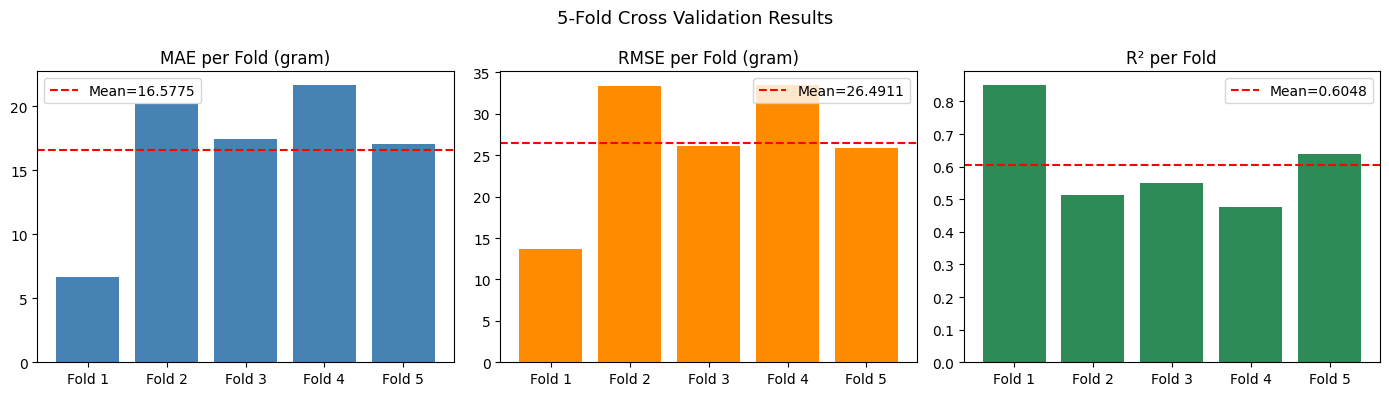

In [ ]:
# plot hasil cross val
fold_labels = [f'Fold {i+1}' for i in range(N_FOLDS)]
x = np.arange(N_FOLDS)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(x, mae_list,  color='steelblue')
axes[0].axhline(np.mean(mae_list),  color='red', linestyle='--', label=f'Mean={np.mean(mae_list):.4f}')
axes[0].set_title('MAE per Fold (gram)')
axes[0].set_xticks(x); axes[0].set_xticklabels(fold_labels)
axes[0].legend()

axes[1].bar(x, rmse_list, color='darkorange')
axes[1].axhline(np.mean(rmse_list), color='red', linestyle='--', label=f'Mean={np.mean(rmse_list):.4f}')
axes[1].set_title('RMSE per Fold (gram)')
axes[1].set_xticks(x); axes[1].set_xticklabels(fold_labels)
axes[1].legend()

axes[2].bar(x, r2_list,   color='seagreen')
axes[2].axhline(np.mean(r2_list),   color='red', linestyle='--', label=f'Mean={np.mean(r2_list):.4f}')
axes[2].set_title('R² per Fold')
axes[2].set_xticks(x); axes[2].set_xticklabels(fold_labels)
axes[2].legend()

plt.suptitle('5-Fold Cross Validation Results', fontsize=13)
plt.tight_layout()
plt.show()

Dari visualisasi diatas, 5-fold CV menunjukkan variasi performa yang cukup tinggi antar fold, terlihat dari R² yang berkisar antara 0.39 hingga 0.85. Fold 1 menjadi yang terbaik, sementara Fold 4 paling lemah. Variasi ini cukup wajar karena ukuran dataset yang bisa dibilang kecil dan tidak seimbang. Mean MAE 16.66 gram dari CV lebih tinggi dibanding hasil test set (6.46 gram) yang menunjukkan bahwa model utama mendapat split data yang relatif lebih menguntungkan.


# XAI: Grad-CAM

In [ ]:
# ambil last convolution layer
last_conv_layer_name = 'top_conv'
print('Using last conv layer:', last_conv_layer_name)

Using last conv layer: top_conv


In [ ]:
# set up untuk dual input
backbone_cam = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and 'efficientnet' in layer.name.lower():
        backbone_cam = layer
        break

print('Backbone:', backbone_cam.name if backbone_cam is not None else 'Not found')

cam_backbone = keras.Model(
    inputs=backbone_cam.input,
    outputs=[backbone_cam.get_layer(last_conv_layer_name).output, backbone_cam.output]
)

dense_layers = [l for l in model.layers if isinstance(l, layers.Dense)]
print('Dense layers:', [l.name for l in dense_layers])

Backbone: efficientnetb0
Dense layers: ['dense', 'after_ratio']


In [ ]:
# fungsi grad cam
def make_dual_gradcam(before_img_array, after_img_array, branch='after'):
    with tf.GradientTape() as tape:
        before_conv, before_feat = cam_backbone(before_img_array, training=False)
        after_conv, after_feat = cam_backbone(after_img_array,   training=False)

        if branch == 'before':
            tape.watch(before_conv)
        else:
            tape.watch(after_conv)

        fusion = tf.concat([before_feat, after_feat], axis=-1)
        x = fusion
        for layer in model.layers:
            if layer.name in ['fusion_concat', 'before_image', 'after_image']:
                continue
            if isinstance(layer, tf.keras.Model):
                continue
            if isinstance(layer, (layers.Dropout, layers.Dense)):
                x = layer(x)

        pred = x[:, 0]

    target_conv  = before_conv if branch == 'before' else after_conv
    grads = tape.gradient(pred, target_conv)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = target_conv[0]
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img).astype('float32') / 255.0

    heatmap_uint8 = np.uint8(255 * heatmap)
    cmap = plt.colormaps['jet']
    colored = cmap(np.arange(256))[:, :3]
    heatmap_rgb = colored[heatmap_uint8]
    heatmap_rgb = tf.image.resize(heatmap_rgb, (IMG_SIZE, IMG_SIZE)).numpy()

    overlay = np.clip((1 - alpha) * img + alpha * heatmap_rgb, 0, 1)
    return img, overlay

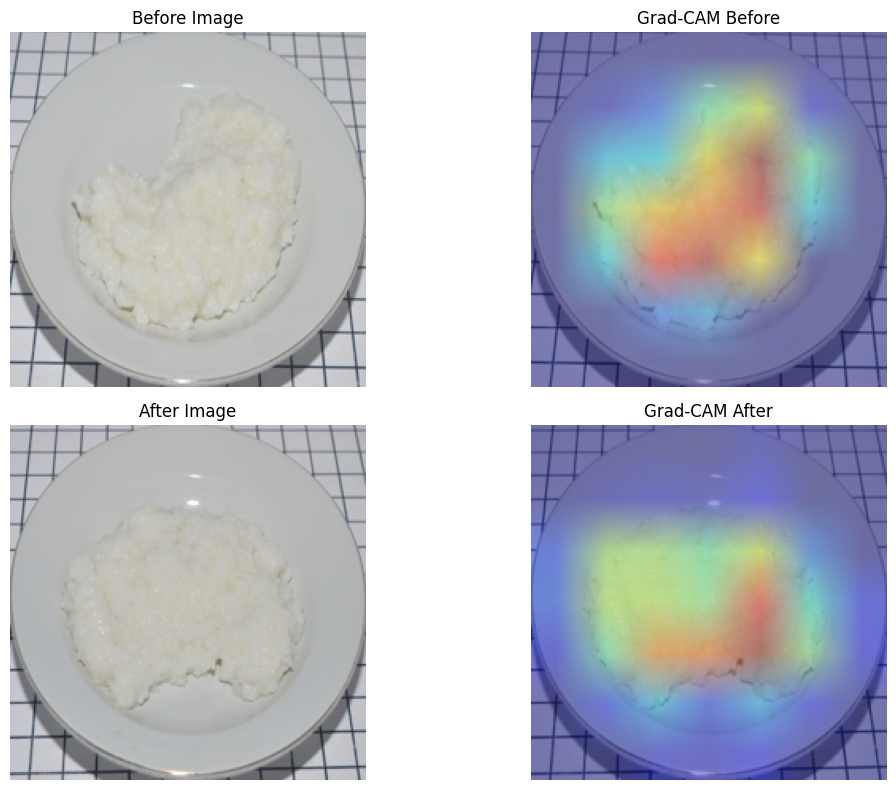

Food : Bubur
Weight before : 343.00 g
Actual after : 330.00 g
Pred after : 301.05 g
Actual ratio : 0.9621
Pred ratio : 0.8777


In [ ]:
# apply function dan visualisasi grad cam
cam_df = show_df.sort_values('weight_after', ascending=False).reset_index(drop=True)
row = cam_df.iloc[0]

before_img = load_image(row['before_path'])
after_img  = load_image(row['after_path'])

before_pp = tf.keras.applications.efficientnet.preprocess_input(before_img)
after_pp = tf.keras.applications.efficientnet.preprocess_input(after_img)

before_arr = np.expand_dims(before_pp.numpy(), axis=0)
after_arr = np.expand_dims(after_pp.numpy(), axis=0)

heatmap_before = make_dual_gradcam(before_arr, after_arr, branch='before')
heatmap_after = make_dual_gradcam(before_arr, after_arr, branch='after')

orig_before, overlay_before = overlay_gradcam(row['before_path'], heatmap_before, alpha=0.4)
orig_after,  overlay_after  = overlay_gradcam(row['after_path'],  heatmap_after,  alpha=0.4)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(orig_before)
plt.title('Before Image')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(overlay_before)
plt.title('Grad-CAM Before')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(orig_after)
plt.title('After Image')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(overlay_after)
plt.title('Grad-CAM After')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f'Food : {row['Name of the food']}')
print(f'Weight before : {row['weight_before']:.2f} g')
print(f'Actual after : {row['weight_after']:.2f} g')
print(f'Pred after : {row['pred_after_g']:.2f} g')
print(f'Actual ratio : {row['after_ratio']:.4f}')
print(f'Pred ratio : {row['pred_ratio']:.4f}')